# Brain Tumor MRI Classification — Exploratory Data Analysis
**DATASCI 281 Final Project**  
Aaron Luong, Amanda Chung, Caitlin Gainey, Clara Rhoades

Claude helped write first drafts for much of the code for this notebook.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import cv2
from pathlib import Path
from collections import Counter

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

## Data Loading & Structure Verification

In [2]:
DATA_DIR = Path('../tumor_data/raw')
TRAIN_DIR = DATA_DIR / 'Training'
TEST_DIR = DATA_DIR / 'Testing'

BACKUP_DATA_DIR = Path('../tumor_data_backup/raw')
BACKUP_TRAIN_DIR = BACKUP_DATA_DIR / 'Training'
BACKUP_TEST_DIR = BACKUP_DATA_DIR / 'Testing'

CLASSES = sorted([d.name for d in TRAIN_DIR.iterdir() if d.is_dir()])
print(f'Data directory: {DATA_DIR.resolve()}')
print(f'Classes found: {CLASSES}')
print(f'\nTraining subfolders: {sorted(os.listdir(TRAIN_DIR))}')
print(f'Testing subfolders:  {sorted(os.listdir(TEST_DIR))}')

Data directory: /Users/cekr/Documents/00_281/tumor_data/raw
Classes found: ['glioma', 'meningioma', 'notumor', 'pituitary']

Training subfolders: ['glioma', 'meningioma', 'notumor', 'pituitary']
Testing subfolders:  ['glioma', 'meningioma', 'notumor', 'pituitary']


## Duplicate Image Detection (Train/Test Leakage Check)

In [3]:
all_paths = []
for cls in CLASSES:
    for fpath in sorted((BACKUP_TRAIN_DIR / cls).iterdir()):
        if fpath.suffix.lower() in ('.jpg', '.jpeg', '.png'):
            all_paths.append((fpath, cls, 'Training'))
    for fpath in sorted((BACKUP_TEST_DIR / cls).iterdir()):
        if fpath.suffix.lower() in ('.jpg', '.jpeg', '.png'):
            all_paths.append((fpath, cls, 'Testing'))

In [5]:
import hashlib

def file_hash(fpath):
    """Fast MD5 hash of raw file bytes."""
    h = hashlib.md5()
    with open(fpath, 'rb') as f:
        h.update(f.read())
    return h.hexdigest()

hash_to_files = {}
for fpath, cls, split in all_paths:
    h = file_hash(fpath)
    if h not in hash_to_files:
        hash_to_files[h] = []
    hash_to_files[h].append({'path': str(fpath), 'class': cls, 'split': split})

duplicates = {h: files for h, files in hash_to_files.items() if len(files) > 1}

# Categorize
within_train = []
within_test = []
cross_split = []

for h, files in duplicates.items():
    splits = set(f['split'] for f in files)
    if splits == {'Training'}:
        within_train.append(files)
    elif splits == {'Testing'}:
        within_test.append(files)
    else:
        cross_split.append(files)

print(f'=== Duplicate Image Detection (all {len(all_paths)} images) ===')
print(f'Unique hashes:              {len(hash_to_files)}')
print(f'Duplicate groups found:     {len(duplicates)}')
print(f'  Within training set:      {len(within_train)}')
print(f'  Within test set:          {len(within_test)}')
print(f'  Cross train↔test (LEAK):  {len(cross_split)}')

if cross_split:
    print(f'\n⚠️  TRAIN/TEST LEAKAGE DETECTED:')
    for group in cross_split[:5]:
        print(f'  Group:')
        for f in group:
            print(f'    {Path(f["path"]).name} ({f["class"]}, {f["split"]})')
    if len(cross_split) > 5:
        print(f'  ... and {len(cross_split) - 5} more groups')
    print(f'\n→ Recommendation: Remove duplicates from test set or re-split.')
elif duplicates:
    print(f'\n⚠️  Duplicates found within splits — consider deduplication.')
else:
    print(f'\n✅ No duplicate images found.')

=== Duplicate Image Detection (all 7200 images) ===
Unique hashes:              7013
Duplicate groups found:     153
  Within training set:      138
  Within test set:          15
  Cross train↔test (LEAK):  0

⚠️  Duplicates found within splits — consider deduplication.


## Deduplicate Training & Test Sets

In [6]:
# For each group of exact duplicates, keep the first file (alphabetically)
# and delete the rest. Operates on the raw data directory — back up first!

import hashlib
import shutil
from pathlib import Path

# --- Build hash map (reuses all_paths from earlier cells) ---
def file_hash(fpath):
    h = hashlib.md5()
    with open(fpath, 'rb') as f:
        h.update(f.read())
    return h.hexdigest()

hash_to_files = {}
for fpath, cls, split in all_paths:
    h = file_hash(fpath)
    if h not in hash_to_files:
        hash_to_files[h] = []
    hash_to_files[h].append({'path': str(fpath), 'class': cls, 'split': split})

duplicates = {h: files for h, files in hash_to_files.items() if len(files) > 1}

# --- Preview what will be removed ---
to_remove = []
for h, files in duplicates.items():
    # Sort by path so the "keep" choice is deterministic
    files_sorted = sorted(files, key=lambda f: f['path'])
    keep = files_sorted[0]
    remove = files_sorted[1:]
    to_remove.extend(remove)

print(f'Duplicate groups:    {len(duplicates)}')
print(f'Images to KEEP:      {len(duplicates)} (one per group)')
print(f'Images to REMOVE:    {len(to_remove)}')
print(f'Dataset size before: {len(all_paths)}')
print(f'Dataset size after:  {len(all_paths) - len(to_remove)}')

# Breakdown by split
train_removals = [f for f in to_remove if f['split'] == 'Training']
test_removals  = [f for f in to_remove if f['split'] == 'Testing']
print(f'\n  Training removals: {len(train_removals)}')
print(f'  Test removals:     {len(test_removals)}')

# Breakdown by class
print(f'\n  Removals by class:')
for cls in CLASSES:
    n = len([f for f in to_remove if f['class'] == cls])
    print(f'    {cls:15s} {n}')

# --- Show a few examples ---
print(f'\nSample removals (first 10):')
for f in to_remove[:10]:
    print(f'  {Path(f["path"]).name:30s} ({f["class"]}, {f["split"]})')

# # --- Uncomment below to actually delete ---
# confirm = input('\nType "yes" to delete duplicates: ')
# if confirm.strip().lower() == 'yes':
#     for f in to_remove:
#         Path(f['path']).unlink()
#         print(f'  Deleted: {f["path"]}')
#     print(f'\nRemoved {len(to_remove)} duplicate images.')
# else:
#     print('Aborted — no files deleted.')

Duplicate groups:    153
Images to KEEP:      153 (one per group)
Images to REMOVE:    187
Dataset size before: 7200
Dataset size after:  7013

  Training removals: 171
  Test removals:     16

  Removals by class:
    glioma          14
    meningioma      16
    notumor         119
    pituitary       38

Sample removals (first 10):
  Te-gl_303.jpg                  (glioma, Testing)
  Te-gl_238.jpg                  (glioma, Testing)
  Te-gl_72.jpg                   (glioma, Testing)
  Te-gl_59.jpg                   (glioma, Testing)
  Te-gl_278.jpg                  (glioma, Testing)
  Te-gl_178.jpg                  (glioma, Testing)
  Te-gl_228.jpg                  (glioma, Testing)
  Te-gl_36.jpg                   (glioma, Testing)
  Te-gl_259.jpg                  (glioma, Testing)
  Te-gl_272.jpg                  (glioma, Testing)


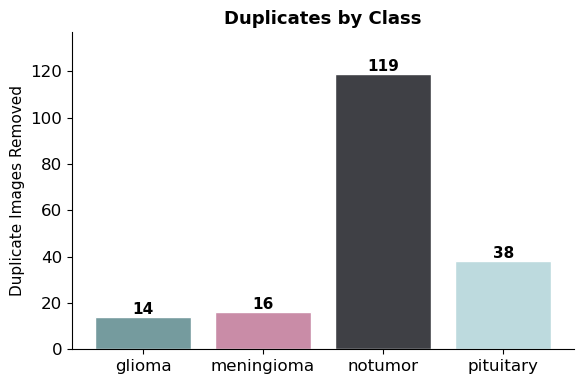

In [7]:
import matplotlib.pyplot as plt
import numpy as np

CLASS_COLORS = {
    'glioma':     '#759b9e',
    'meningioma': '#c98ca7',
    'notumor':    '#3f4045',
    'pituitary':  '#bddade',
}

# Count duplicates removed per class (one kept per group, rest removed)
dup_counts = {cls: 0 for cls in CLASSES}
for f in to_remove:
    dup_counts[f['class']] += 1

fig, ax = plt.subplots(figsize=(6, 4))
classes = list(dup_counts.keys())
counts = [dup_counts[c] for c in classes]
colors = [CLASS_COLORS[c] for c in classes]

bars = ax.bar(classes, counts, color=colors, edgecolor='white', linewidth=1)
for bar, n in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
            str(n), ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_ylabel('Duplicate Images Removed', fontsize=11)
ax.set_title('Duplicates by Class', fontsize=13, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylim(0, max(counts) * 1.15)
plt.tight_layout()
plt.savefig('duplicates_by_class.png', dpi=200, bbox_inches='tight')
plt.show()

## Class Distribution

In [6]:
def count_images(base_dir, classes):
    """Count images per class in a directory."""
    counts = {}
    for cls in classes:
        folder = base_dir / cls
        imgs = [f for f in folder.iterdir() if f.suffix.lower() in ('.jpg', '.jpeg', '.png')]
        counts[cls] = len(imgs)
    return counts

train_counts = count_images(TRAIN_DIR, CLASSES)
test_counts = count_images(TEST_DIR, CLASSES)

print('Training set:')
for cls, n in train_counts.items():
    print(f'  {cls:15s} {n:5d}')
print(f'  {"TOTAL":15s} {sum(train_counts.values()):5d}')

print('\nTest set:')
for cls, n in test_counts.items():
    print(f'  {cls:15s} {n:5d}')
print(f'  {"TOTAL":15s} {sum(test_counts.values()):5d}')

Training set:
  glioma           1400
  meningioma       1386
  notumor          1281
  pituitary        1362
  TOTAL            5429

Test set:
  glioma            386
  meningioma        398
  notumor           400
  pituitary         400
  TOTAL            1584


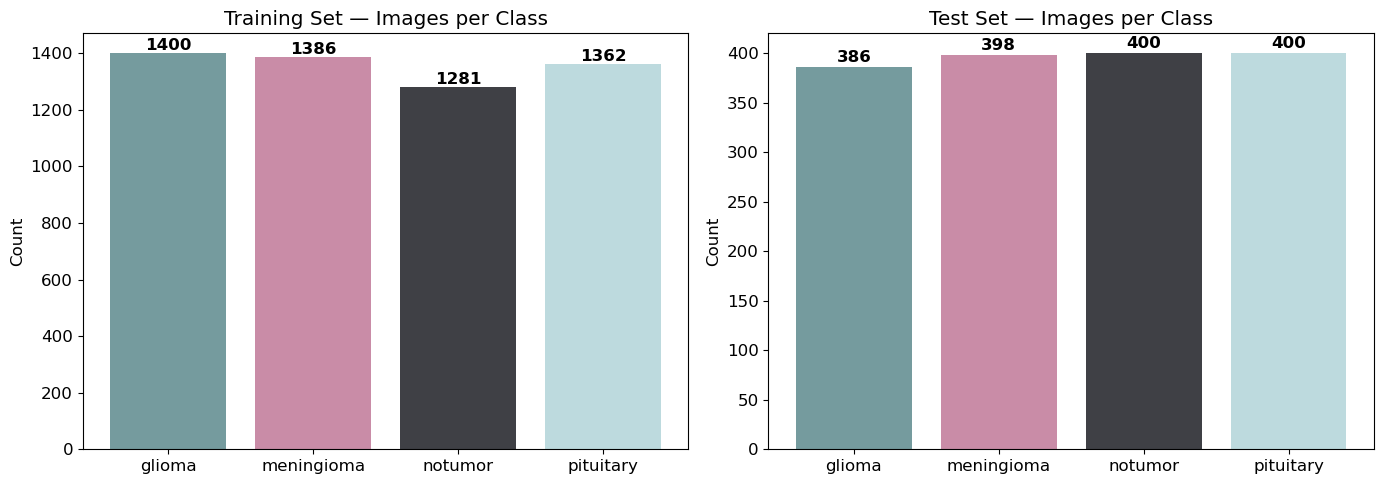

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#759b9e', '#c98ca7', '#3f4045', '#bddade']

axes[0].bar(train_counts.keys(), train_counts.values(), color=colors)
axes[0].set_title('Training Set — Images per Class')
axes[0].set_ylabel('Count')
for i, (cls, n) in enumerate(train_counts.items()):
    axes[0].text(i, n + 10, str(n), ha='center', fontweight='bold')

axes[1].bar(test_counts.keys(), test_counts.values(), color=colors)
axes[1].set_title('Test Set — Images per Class')
axes[1].set_ylabel('Count')
for i, (cls, n) in enumerate(test_counts.items()):
    axes[1].text(i, n + 5, str(n), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

## Sample Images by Class

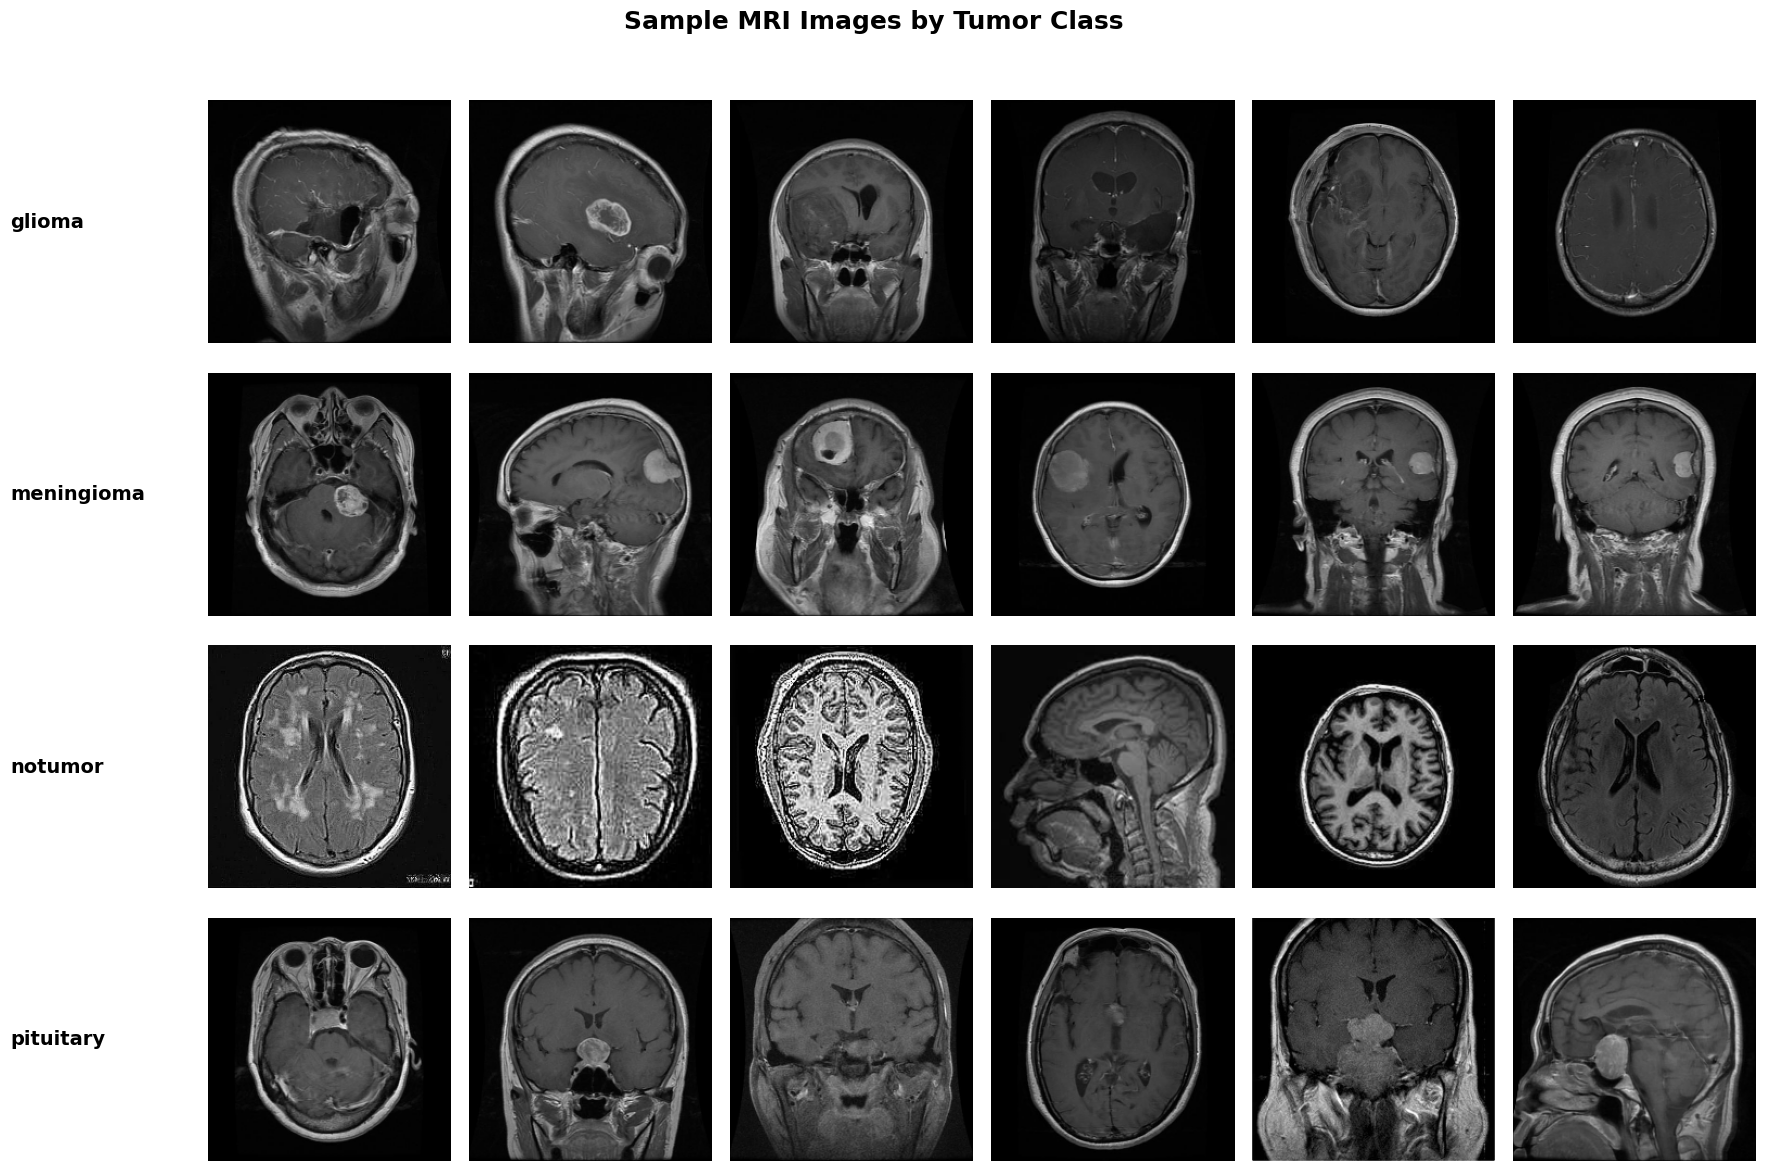

In [18]:
np.random.seed(79)
N_SAMPLES = 6
DISPLAY_SIZE = (224, 224)

fig, axes = plt.subplots(len(CLASSES), N_SAMPLES, figsize=(18, 12))

for row, cls in enumerate(CLASSES):
    folder = TRAIN_DIR / cls
    all_imgs = sorted([f for f in folder.iterdir() if f.suffix.lower() in ('.jpg', '.jpeg', '.png')])
    sample = np.random.choice(len(all_imgs), size=N_SAMPLES, replace=False)
    
    for col, idx in enumerate(sample):
        img = cv2.imread(str(all_imgs[idx]))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, DISPLAY_SIZE)
        
        axes[row, col].imshow(img)
        axes[row, col].axis('off')

plt.suptitle('Sample MRI Images by Tumor Class', fontsize=18, fontweight='bold')
plt.tight_layout(rect=[0.12, 0, 1, 0.96])

# Add labels ONLY after tight_layout
for row, cls in enumerate(CLASSES):
    y_pos = axes[row, 0].get_position().y0 + axes[row, 0].get_position().height / 2
    fig.text(0.02, y_pos, cls, fontsize=14, fontweight='bold', va='center', ha='left')

plt.savefig('sample_grid.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

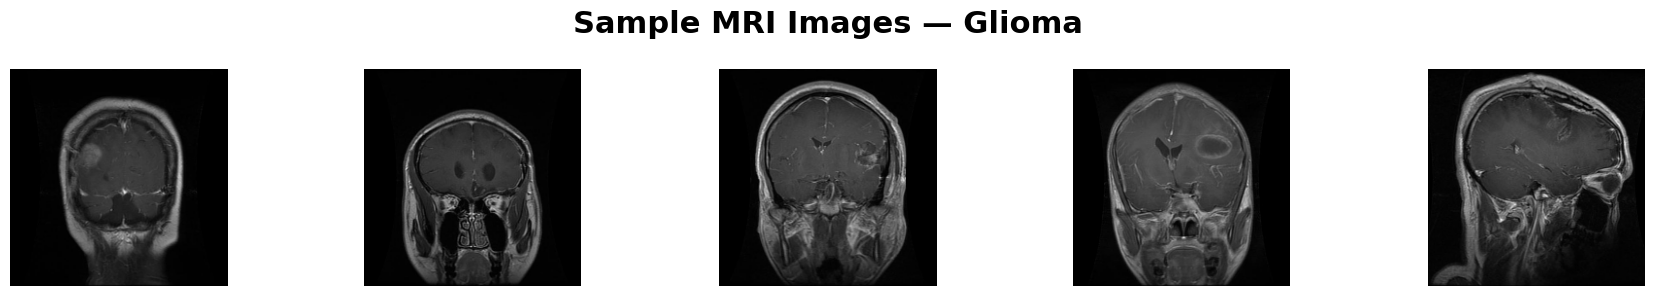

In [14]:
# Cell 1 — Glioma
np.random.seed(99)
N_SAMPLES = 5
DISPLAY_SIZE = (224, 224)
cls = 'glioma'

folder = TRAIN_DIR / cls
all_imgs = sorted([f for f in folder.iterdir() if f.suffix.lower() in ('.jpg', '.jpeg', '.png')])
sample = np.random.choice(len(all_imgs), size=N_SAMPLES, replace=False)

fig, axes = plt.subplots(1, N_SAMPLES, figsize=(18, 3))
for col, idx in enumerate(sample):
    img = cv2.imread(str(all_imgs[idx]))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, DISPLAY_SIZE)
    axes[col].imshow(img)
    axes[col].axis('off')

plt.suptitle(f'Sample MRI Images — {cls.capitalize()}', fontsize=22, fontweight='bold')
plt.tight_layout()
plt.savefig(f'sample_grid_{cls}.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

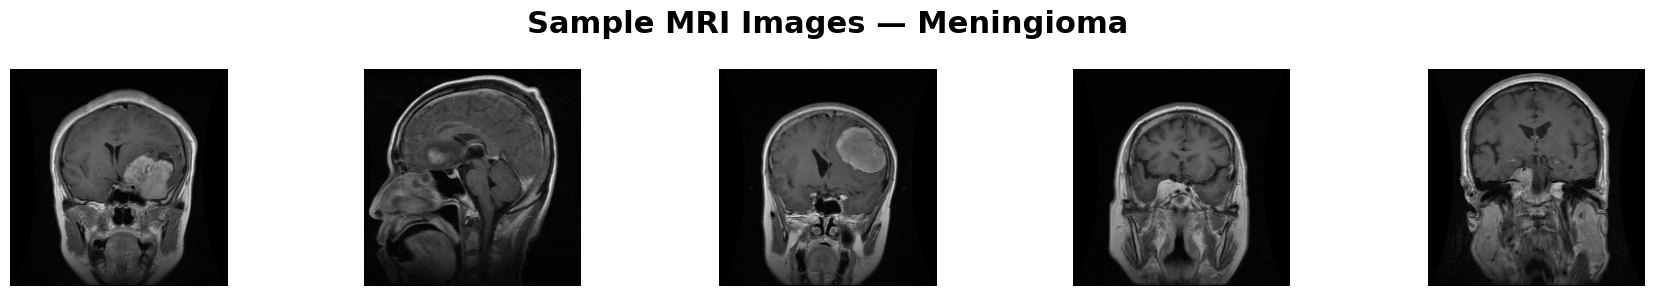

In [15]:
# Cell 2 — Meningioma
np.random.seed(79)
N_SAMPLES = 5
DISPLAY_SIZE = (224, 224)
cls = 'meningioma'

folder = TRAIN_DIR / cls
all_imgs = sorted([f for f in folder.iterdir() if f.suffix.lower() in ('.jpg', '.jpeg', '.png')])
sample = np.random.choice(len(all_imgs), size=N_SAMPLES, replace=False)

fig, axes = plt.subplots(1, N_SAMPLES, figsize=(18, 3))
for col, idx in enumerate(sample):
    img = cv2.imread(str(all_imgs[idx]))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, DISPLAY_SIZE)
    axes[col].imshow(img)
    axes[col].axis('off')

plt.suptitle(f'Sample MRI Images — {cls.capitalize()}', fontsize=22, fontweight='bold')
plt.tight_layout()
plt.savefig(f'sample_grid_{cls}.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

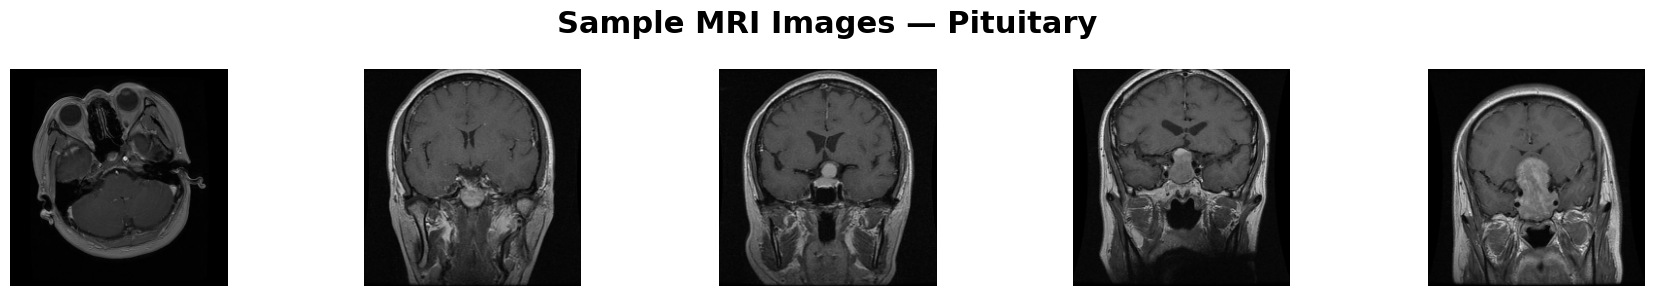

In [16]:
# Cell 3 — Pituitary
np.random.seed(79)
N_SAMPLES = 5
DISPLAY_SIZE = (224, 224)
cls = 'pituitary'

folder = TRAIN_DIR / cls
all_imgs = sorted([f for f in folder.iterdir() if f.suffix.lower() in ('.jpg', '.jpeg', '.png')])
sample = np.random.choice(len(all_imgs), size=N_SAMPLES, replace=False)

fig, axes = plt.subplots(1, N_SAMPLES, figsize=(18, 3))
for col, idx in enumerate(sample):
    img = cv2.imread(str(all_imgs[idx]))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, DISPLAY_SIZE)
    axes[col].imshow(img)
    axes[col].axis('off')

plt.suptitle(f'Sample MRI Images — {cls.capitalize()}', fontsize=22, fontweight='bold')
plt.tight_layout()
plt.savefig(f'sample_grid_{cls}.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

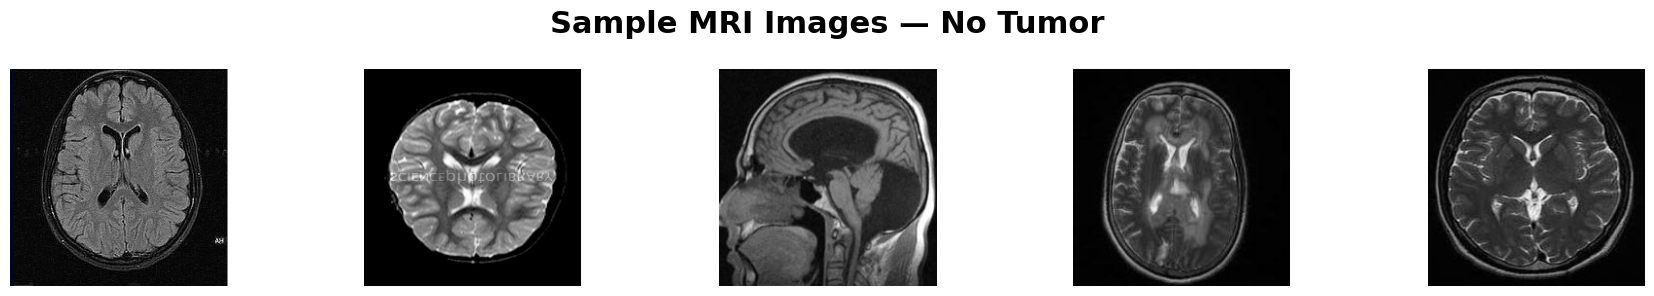

In [23]:
# Cell 4 — No Tumor
np.random.seed(2)
N_SAMPLES = 5
DISPLAY_SIZE = (224, 224)
cls = 'notumor'

folder = TRAIN_DIR / cls
all_imgs = sorted([f for f in folder.iterdir() if f.suffix.lower() in ('.jpg', '.jpeg', '.png')])
sample = np.random.choice(len(all_imgs), size=N_SAMPLES, replace=False)

fig, axes = plt.subplots(1, N_SAMPLES, figsize=(18, 3))
for col, idx in enumerate(sample):
    img = cv2.imread(str(all_imgs[idx]))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, DISPLAY_SIZE)
    axes[col].imshow(img)
    axes[col].axis('off')

plt.suptitle('Sample MRI Images — No Tumor', fontsize=22, fontweight='bold')
plt.tight_layout()
plt.savefig(f'sample_grid_{cls}.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

## Pixel Value Ranges & Dtype Check

In [ ]:
np.random.seed(77)
SAMPLE_N = 300

sample_idx = np.random.choice(len(all_paths), size=min(SAMPLE_N, len(all_paths)), replace=False)

dtypes = Counter()
mins, maxs = [], []
narrow_range = []  # images that don't use much of the [0, 255] range

for idx in sample_idx:
    fpath, cls, split = all_paths[idx]
    img = cv2.imread(str(fpath), cv2.IMREAD_UNCHANGED)  # preserve original dtype
    if img is None:
        continue

    dtypes[str(img.dtype)] += 1
    img_min, img_max = int(img.min()), int(img.max())
    mins.append(img_min)
    maxs.append(img_max)

    # Flag images using less than 30% of the dynamic range
    dynamic_range = img_max - img_min
    if dynamic_range < 0.3 * 255:
        narrow_range.append({
            'path': str(fpath), 'class': cls, 'split': split,
            'min': img_min, 'max': img_max, 'range': dynamic_range
        })

print(f'=== Pixel Value & Dtype Check ({len(sample_idx)} sampled images) ===')
print(f'Dtypes found:      {dict(dtypes)}')
print(f'Global pixel min:  {min(mins)}')
print(f'Global pixel max:  {max(maxs)}')
print(f'Per-image min — min: {min(mins)}, max: {max(mins)}, mean: {np.mean(mins):.1f}')
print(f'Per-image max — min: {min(maxs)}, max: {max(maxs)}, mean: {np.mean(maxs):.1f}')
print(f'\nImages with narrow dynamic range (<30% of [0,255]): {len(narrow_range)}')
if narrow_range:
    for r in narrow_range[:10]:
        print(f'  {Path(r["path"]).name} ({r["class"]}, {r["split"]}) — range: [{r["min"]}, {r["max"]}]')
    if len(narrow_range) > 10:
        print(f'  ... and {len(narrow_range) - 10} more')


=== Pixel Value & Dtype Check (300 sampled images) ===
Dtypes found:      {'uint8': 300}
Global pixel min:  0
Global pixel max:  255
Per-image min — min: 0, max: 26, mean: 0.2
Per-image max — min: 175, max: 255, mean: 253.4

Images with narrow dynamic range (<30% of [0,255]): 0


## Image Resolution Analysis
Catalog every image's width, height, and number of channels.

In [3]:
def catalog_images(base_dir, classes):
    """Collect metadata (width, height, channels, class, split) for all images."""
    records = []
    for cls in classes:
        folder = base_dir / cls
        for fpath in sorted(folder.iterdir()):
            if fpath.suffix.lower() not in ('.jpg', '.jpeg', '.png'):
                continue
            img = cv2.imread(str(fpath))
            if img is None:
                print(f'WARNING: could not read {fpath}')
                continue
            h, w = img.shape[:2]
            ch = img.shape[2] if len(img.shape) == 3 else 1
            records.append({
                'path': str(fpath),
                'class': cls,
                'width': w,
                'height': h,
                'channels': ch,
                'aspect_ratio': w / h
            })
    return records

print('Cataloging training images...')
train_meta = catalog_images(TRAIN_DIR, CLASSES)
print(f'  {len(train_meta)} images cataloged.')

print('Cataloging test images...')
test_meta = catalog_images(TEST_DIR, CLASSES)
print(f'  {len(test_meta)} images cataloged.')

all_meta = train_meta + test_meta

Cataloging training images...
  5429 images cataloged.
Cataloging test images...
  1584 images cataloged.


In [4]:
widths  = np.array([m['width'] for m in all_meta])
heights = np.array([m['height'] for m in all_meta])
ratios  = np.array([m['aspect_ratio'] for m in all_meta])
channels = Counter([m['channels'] for m in all_meta])

print('=== Resolution Summary (all images) ===')
print(f'Width  — min: {widths.min()}, max: {widths.max()}, median: {int(np.median(widths))}, mean: {widths.mean():.0f}')
print(f'Height — min: {heights.min()}, max: {heights.max()}, median: {int(np.median(heights))}, mean: {heights.mean():.0f}')
print(f'Aspect ratio — min: {ratios.min():.2f}, max: {ratios.max():.2f}, median: {np.median(ratios):.2f}')
print(f'Channels: {dict(channels)}')

=== Resolution Summary (all images) ===
Width  — min: 150, max: 1375, median: 512, mean: 453
Height — min: 167, max: 1446, median: 512, mean: 457
Aspect ratio — min: 0.64, max: 1.79, median: 1.00
Channels: {3: 7013}


In [6]:
widths   = np.array([m['width']  for m in all_meta])
heights  = np.array([m['height'] for m in all_meta])
areas    = widths * heights
ratios   = np.array([m['aspect_ratio'] for m in all_meta])
channels = Counter([m['channels'] for m in all_meta])

smallest = all_meta[int(areas.argmin())]
largest  = all_meta[int(areas.argmax())]

print('\n=== Smallest & Largest Images (by total pixel count) ===')
print(f'Smallest: {smallest["width"]}×{smallest["height"]} '
      f'({smallest["width"]*smallest["height"]:,} px)  '
      f'— {smallest["class"]}  — {Path(smallest["path"]).name}')
print(f'Largest:  {largest["width"]}×{largest["height"]} '
      f'({largest["width"]*largest["height"]:,} px)  '
      f'— {largest["class"]}  — {Path(largest["path"]).name}')


=== Smallest & Largest Images (by total pixel count) ===
Smallest: 175×167 (29,225 px)  — glioma  — Te-gl_350.jpg
Largest:  1375×1446 (1,988,250 px)  — notumor  — Tr-no_258.jpg


In [7]:
# Smallest & largest by MAX dimension (longest side)
max_dims = np.maximum(widths, heights)
smallest = all_meta[int(max_dims.argmin())]
largest  = all_meta[int(max_dims.argmax())]

print('=== Smallest & Largest Images (by longest side) ===')
print(f'Smallest: {smallest["width"]}×{smallest["height"]}  '
      f'(max side {max(smallest["width"], smallest["height"])})  '
      f'— {smallest["class"]}  — {Path(smallest["path"]).name}')
print(f'Largest:  {largest["width"]}×{largest["height"]}  '
      f'(max side {max(largest["width"], largest["height"])})  '
      f'— {largest["class"]}  — {Path(largest["path"]).name}')

=== Smallest & Largest Images (by longest side) ===
Smallest: 175×167  (max side 175)  — glioma  — Te-gl_350.jpg
Largest:  1375×1446  (max side 1446)  — notumor  — Tr-no_258.jpg


In [8]:
# Min/max per axis — image with smallest/largest WIDTH
min_w = all_meta[int(widths.argmin())]
max_w = all_meta[int(widths.argmax())]

print('=== Per-Axis Extremes — Width ===')
print(f'Min width: {min_w["width"]}×{min_w["height"]}  '
      f'— {min_w["class"]}  — {Path(min_w["path"]).name}')
print(f'Max width: {max_w["width"]}×{max_w["height"]}  '
      f'— {max_w["class"]}  — {Path(max_w["path"]).name}')

=== Per-Axis Extremes — Width ===
Min width: 150×198  — notumor  — Tr-no_1064.jpg
Max width: 1375×1446  — notumor  — Tr-no_258.jpg


In [9]:
# Min/max per axis — image with smallest/largest HEIGHT
min_h = all_meta[int(heights.argmin())]
max_h = all_meta[int(heights.argmax())]

print('=== Per-Axis Extremes — Height ===')
print(f'Min height: {min_h["width"]}×{min_h["height"]}  '
      f'— {min_h["class"]}  — {Path(min_h["path"]).name}')
print(f'Max height: {max_h["width"]}×{max_h["height"]}  '
      f'— {max_h["class"]}  — {Path(max_h["path"]).name}')

=== Per-Axis Extremes — Height ===
Min height: 175×167  — glioma  — Te-gl_350.jpg
Max height: 1375×1446  — notumor  — Tr-no_258.jpg


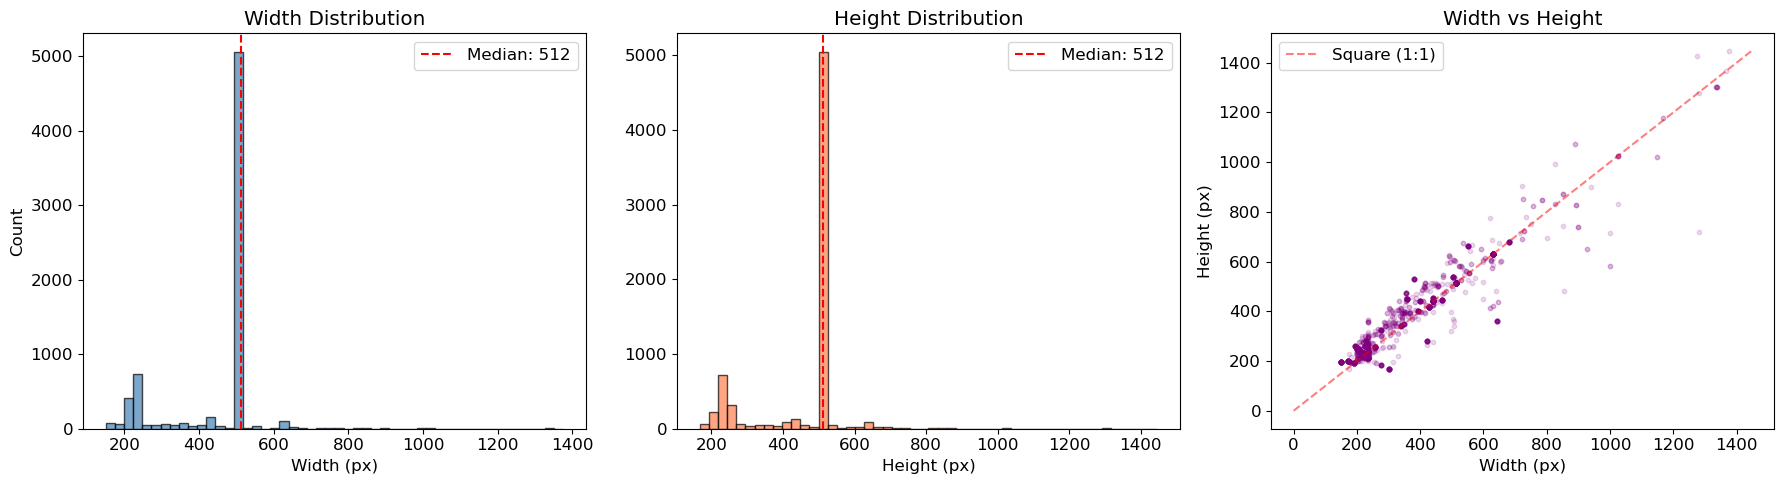

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(widths, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_title('Width Distribution')
axes[0].set_xlabel('Width (px)')
axes[0].set_ylabel('Count')
axes[0].axvline(np.median(widths), color='red', linestyle='--', label=f'Median: {int(np.median(widths))}')
axes[0].legend()

axes[1].hist(heights, bins=50, color='coral', edgecolor='black', alpha=0.7)
axes[1].set_title('Height Distribution')
axes[1].set_xlabel('Height (px)')
axes[1].axvline(np.median(heights), color='red', linestyle='--', label=f'Median: {int(np.median(heights))}')
axes[1].legend()

axes[2].scatter(widths, heights, alpha=0.15, s=10, c='purple')
axes[2].set_title('Width vs Height')
axes[2].set_xlabel('Width (px)')
axes[2].set_ylabel('Height (px)')
axes[2].plot([0, max(widths.max(), heights.max())], [0, max(widths.max(), heights.max())],
             'r--', alpha=0.5, label='Square (1:1)')
axes[2].legend()

plt.tight_layout()
plt.show()

### Resolution Distribution by Class

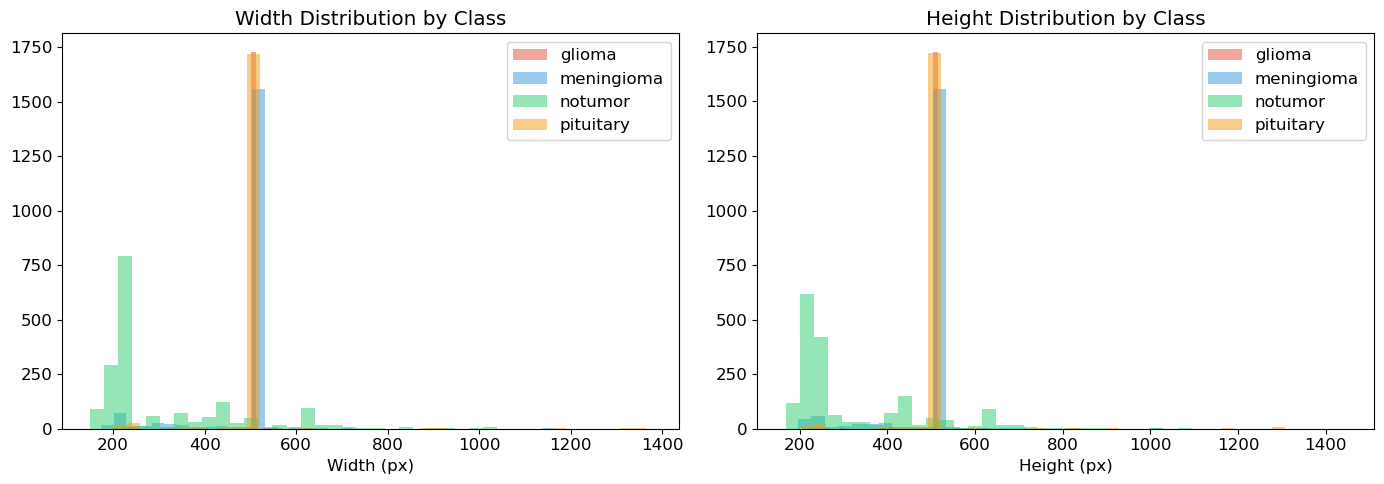

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, cls in enumerate(CLASSES):
    cls_w = [m['width'] for m in all_meta if m['class'] == cls]
    cls_h = [m['height'] for m in all_meta if m['class'] == cls]
    axes[0].hist(cls_w, bins=40, alpha=0.5, label=cls, color=colors[i])
    axes[1].hist(cls_h, bins=40, alpha=0.5, label=cls, color=colors[i])

axes[0].set_title('Width Distribution by Class')
axes[0].set_xlabel('Width (px)')
axes[0].legend()

axes[1].set_title('Height Distribution by Class')
axes[1].set_xlabel('Height (px)')
axes[1].legend()

plt.tight_layout()
plt.show()

## Pixel Intensity Analysis
Sample images from each class and examine their intensity distributions.

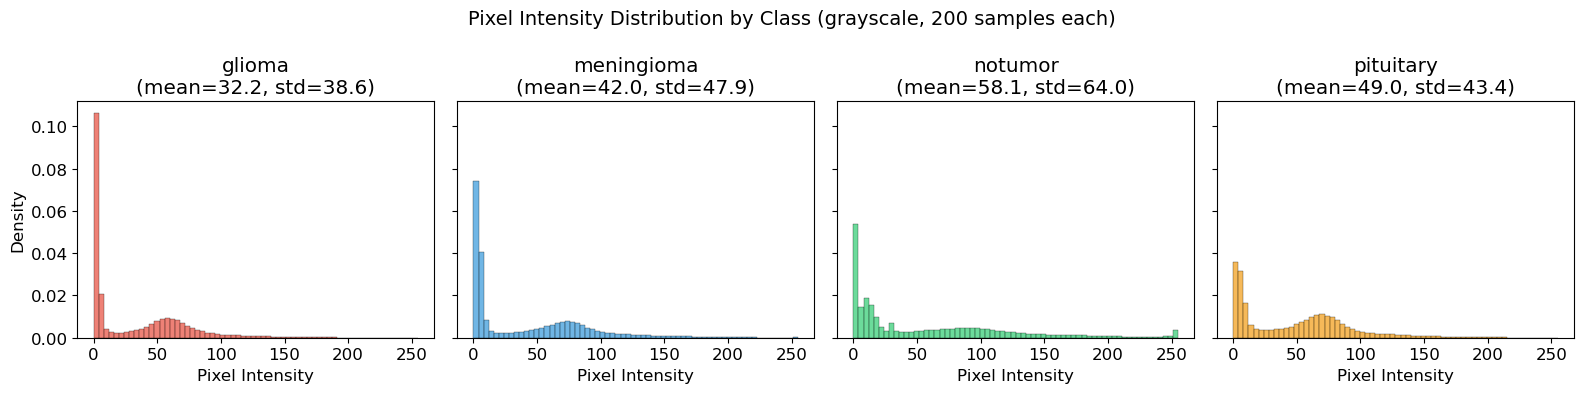

In [10]:
np.random.seed(123)
SAMPLE_PER_CLASS = 200

fig, axes = plt.subplots(1, len(CLASSES), figsize=(16, 4), sharey=True)

for i, cls in enumerate(CLASSES):
    folder = TRAIN_DIR / cls
    all_imgs = sorted([f for f in folder.iterdir() if f.suffix.lower() in ('.jpg', '.jpeg', '.png')])
    sample_paths = np.random.choice(len(all_imgs), size=min(SAMPLE_PER_CLASS, len(all_imgs)), replace=False)
    
    all_pixels = []
    for idx in sample_paths:
        img = cv2.imread(str(all_imgs[idx]), cv2.IMREAD_GRAYSCALE)
        if img is not None:
            all_pixels.append(img.flatten())
    
    all_pixels = np.concatenate(all_pixels)
    axes[i].hist(all_pixels, bins=64, density=True, color=colors[i], alpha=0.7, edgecolor='black', linewidth=0.3)
    axes[i].set_title(f'{cls}\n(mean={all_pixels.mean():.1f}, std={all_pixels.std():.1f})')
    axes[i].set_xlabel('Pixel Intensity')

axes[0].set_ylabel('Density')
plt.suptitle('Pixel Intensity Distribution by Class (grayscale, 200 samples each)', fontsize=14)
plt.tight_layout()
plt.show()

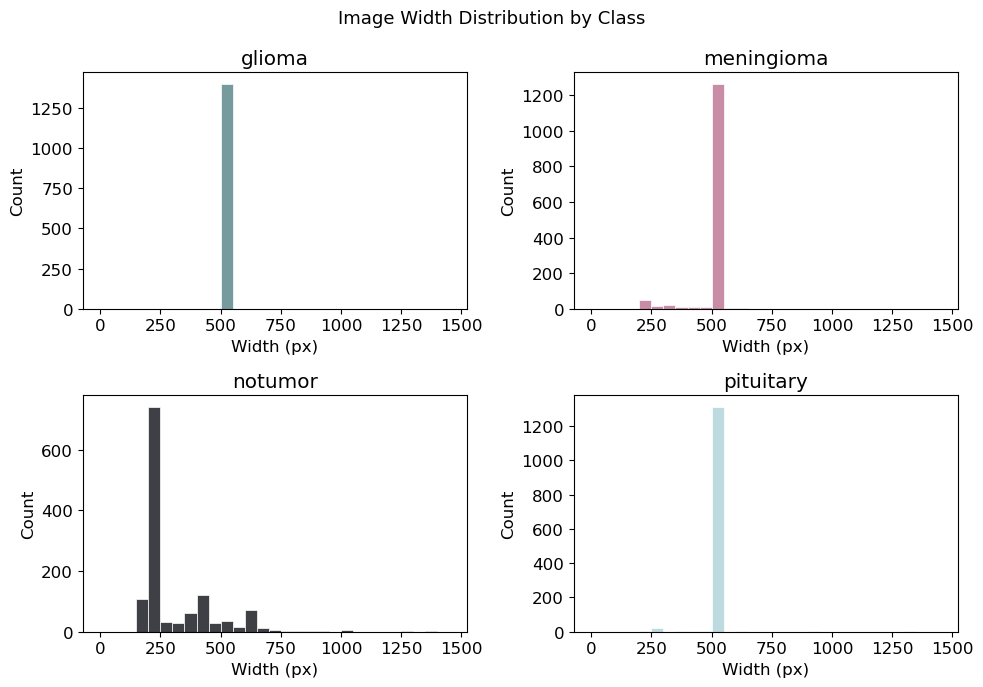

In [8]:
import matplotlib.pyplot as plt
import cv2
from pathlib import Path
from collections import defaultdict

DATA_DIR = Path('../tumor_data/raw')
TRAIN_DIR = DATA_DIR / 'Training'
CLASSES = ['glioma', 'meningioma', 'notumor', 'pituitary']
COLORS = {
    'glioma':     '#759b9e',
    'meningioma': '#c98ca7',
    'notumor':    '#3f4045',
    'pituitary':  '#bddade'
}

widths = defaultdict(list)

for cls in CLASSES:
    for fpath in (TRAIN_DIR / cls).iterdir():
        if fpath.suffix.lower() in ('.jpg', '.jpeg', '.png'):
            img = cv2.imread(str(fpath), cv2.IMREAD_GRAYSCALE)
            if img is not None:
                widths[cls].append(img.shape[1])

bins = range(0, 1500, 50)
fig, axes = plt.subplots(2, 2, figsize=(10, 7))

for ax, cls in zip(axes.flat, CLASSES):
    ax.hist(widths[cls], bins=bins, color=COLORS[cls], edgecolor='white', linewidth=0.5)
    ax.set_title(cls)
    ax.set_xlabel('Width (px)')
    ax.set_ylabel('Count')

plt.suptitle('Image Width Distribution by Class', fontsize=13)
plt.tight_layout()
plt.savefig('resolution_2x2.png', dpi=150, bbox_inches='tight')
plt.show()

## Mean Image per Class
Resize all training images to a common size and compute the per-class average — this can reveal structural patterns and imaging plane biases.

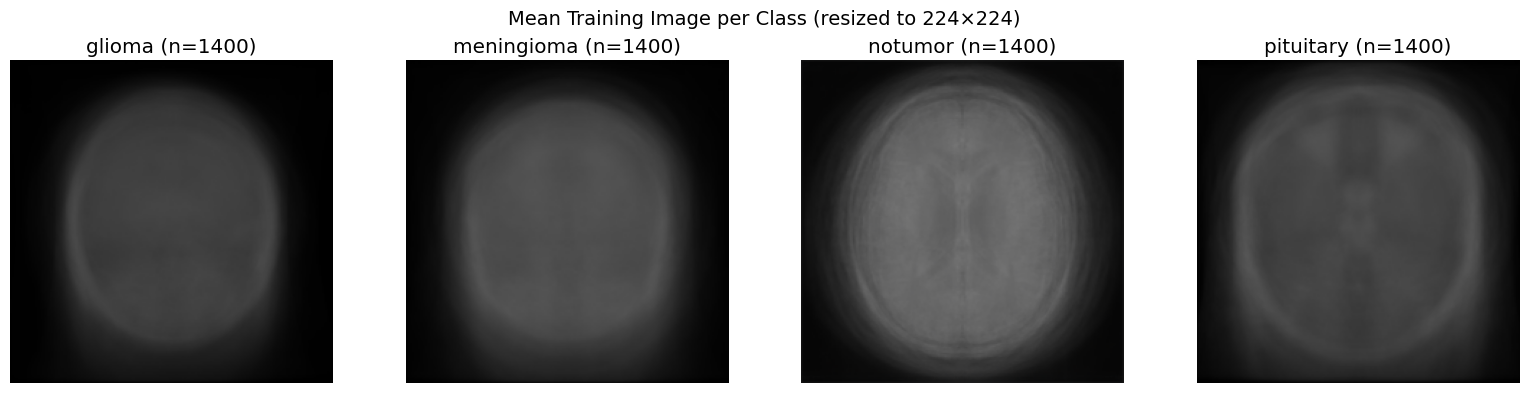

In [11]:
TARGET_SIZE = (224, 224)

fig, axes = plt.subplots(1, len(CLASSES), figsize=(16, 4))

for i, cls in enumerate(CLASSES):
    folder = TRAIN_DIR / cls
    all_imgs = sorted([f for f in folder.iterdir() if f.suffix.lower() in ('.jpg', '.jpeg', '.png')])
    
    accumulator = np.zeros((*TARGET_SIZE, 3), dtype=np.float64)
    count = 0
    
    for fpath in all_imgs:
        img = cv2.imread(str(fpath))
        if img is None:
            continue
        img = cv2.resize(img, TARGET_SIZE)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        accumulator += img.astype(np.float64)
        count += 1
    
    mean_img = (accumulator / count).astype(np.uint8)
    axes[i].imshow(mean_img)
    axes[i].set_title(f'{cls} (n={count})')
    axes[i].axis('off')

plt.suptitle('Mean Training Image per Class (resized to 224×224)', fontsize=14)
plt.tight_layout()
plt.show()

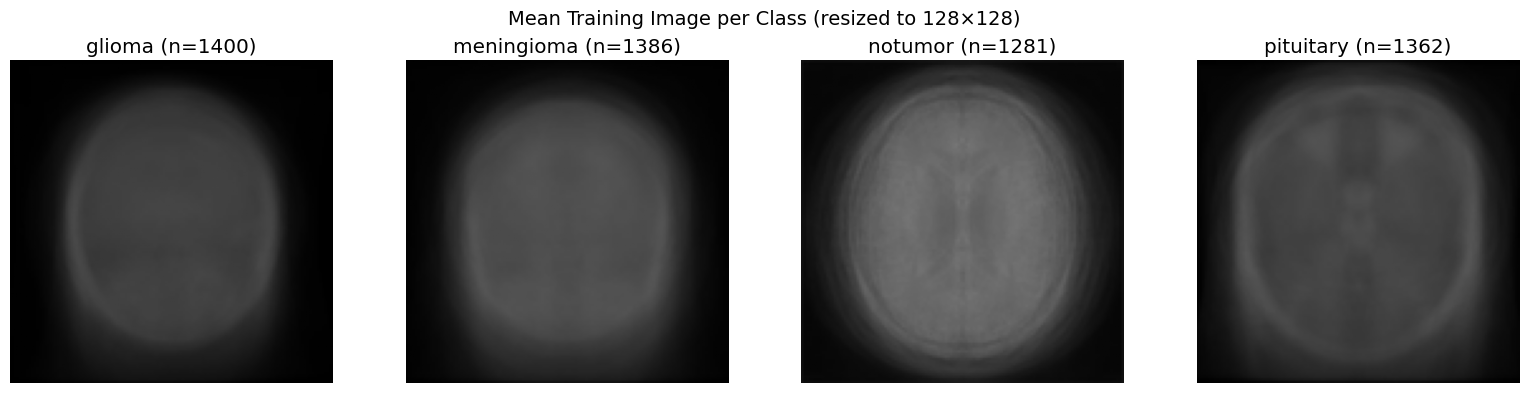

In [4]:
# update mean image analysis to match main pipeline in order to get image for report
from PIL import Image

TARGET_SIZE = (128, 128)

fig, axes = plt.subplots(1, len(CLASSES), figsize=(16, 4))

for i, cls in enumerate(CLASSES):
    folder = TRAIN_DIR / cls
    all_imgs = sorted([f for f in folder.iterdir() if f.suffix.lower() in ('.jpg', '.jpeg', '.png')])
    
    accumulator = np.zeros(TARGET_SIZE, dtype=np.float64)
    count = 0
    
    for fpath in all_imgs:
        img = Image.open(fpath).convert('L')
        img = img.resize(TARGET_SIZE, Image.LANCZOS)
        arr = np.array(img, dtype=np.float32) / 255.0
        accumulator += arr
        count += 1
    
    mean_img = accumulator / count
    axes[i].imshow(mean_img, cmap='gray', vmin=0, vmax=1)
    axes[i].set_title(f'{cls} (n={count})')
    axes[i].axis('off')

plt.suptitle('Mean Training Image per Class (resized to 128×128)', fontsize=14)
plt.tight_layout()
plt.show()

## Grayscale vs. Color Check
Even though MRIs are grayscale, the files may be saved as 3-channel images. Let's verify whether any images have actual color information or if all three channels are identical.

In [8]:
np.random.seed(99)
SAMPLE_CHECK = 300

all_train_paths = []
for cls in CLASSES:
    folder = TRAIN_DIR / cls
    all_train_paths.extend([f for f in folder.iterdir() if f.suffix.lower() in ('.jpg', '.jpeg', '.png')])

sample_indices = np.random.choice(len(all_train_paths), size=SAMPLE_CHECK, replace=False)

truly_color = 0
truly_gray = 0
single_channel = 0

for idx in sample_indices:
    img = cv2.imread(str(all_train_paths[idx]))
    if img is None:
        continue
    if len(img.shape) == 2:
        single_channel += 1
    else:
        # Check if all channels are identical
        if np.array_equal(img[:,:,0], img[:,:,1]) and np.array_equal(img[:,:,1], img[:,:,2]):
            truly_gray += 1
        else:
            truly_color += 1

print(f'Sampled {SAMPLE_CHECK} images:')
print(f'  Single channel (grayscale):        {single_channel}')
print(f'  3-channel but identical (grayscale): {truly_gray}')
print(f'  3-channel with real color:           {truly_color}')
print(f'\n→ Recommendation: {"Load as grayscale for simple features, convert to 3-ch for ResNet" if truly_color == 0 else "Some images have real color info — investigate further"}')

Sampled 300 images:
  Single channel (grayscale):        0
  3-channel but identical (grayscale): 297
  3-channel with real color:           3

→ Recommendation: Some images have real color info — investigate further


In [9]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from pathlib import Path

# --- Step 1: find all genuinely RGB images (channels differ) ---
def is_color(fpath, tol=2):
    """True if R/G/B channels meaningfully differ (not just a grayscale in RGB container)."""
    img = np.array(Image.open(fpath).convert('RGB'))
    r, g, b = img[..., 0], img[..., 1], img[..., 2]
    return (np.abs(r.astype(int) - g.astype(int)).mean() > tol or
            np.abs(g.astype(int) - b.astype(int)).mean() > tol)

color_paths = []
for fpath, cls, split in all_paths:
    try:
        if is_color(fpath):
            color_paths.append((fpath, cls, split))
    except Exception:
        pass

print(f'Found {len(color_paths)} genuine RGB images')
print('By class:', {c: sum(1 for _, cls, _ in color_paths if cls == c) for c in CLASSES})

Found 30 genuine RGB images
By class: {'glioma': 0, 'meningioma': 0, 'notumor': 30, 'pituitary': 0}


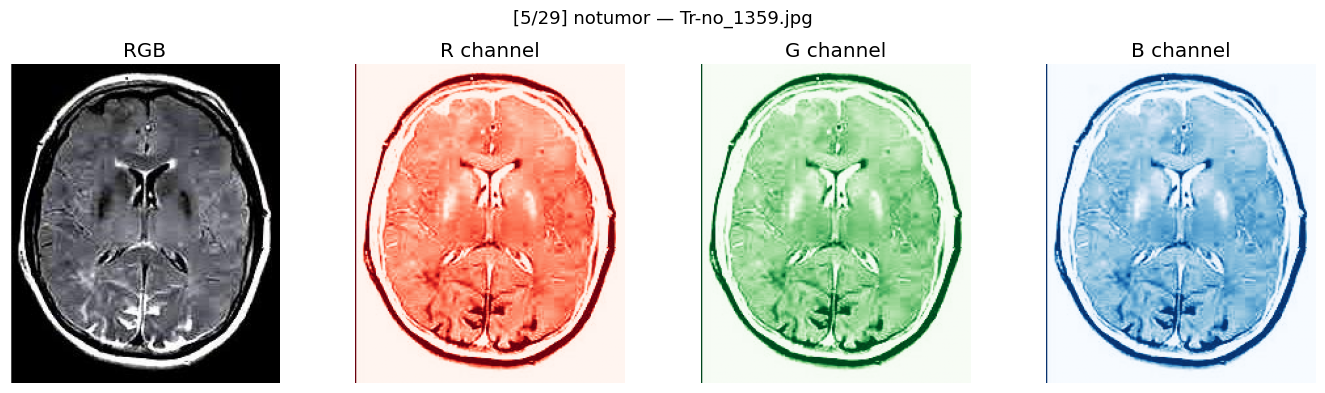

Next run will show idx=6. Set `idx = N` manually to jump.


In [17]:
# --- Step 2: cycle through them one at a time ---
# Re-run this cell to see the next image. Adjust `idx` to jump around.

if 'idx' not in globals():
    idx = 0

fpath, cls, split = color_paths[idx]
img = np.array(Image.open(fpath).convert('RGB'))

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
axes[0].imshow(img);              axes[0].set_title('RGB')
axes[1].imshow(img[..., 0], cmap='Reds');   axes[1].set_title('R channel')
axes[2].imshow(img[..., 1], cmap='Greens'); axes[2].set_title('G channel')
axes[3].imshow(img[..., 2], cmap='Blues');  axes[3].set_title('B channel')
for ax in axes:
    ax.axis('off')
fig.suptitle(f'[{idx}/{len(color_paths)-1}] {cls} — {fpath.name}', fontsize=13)
plt.tight_layout()
plt.show()

idx = (idx + 1) % len(color_paths)   # advance for next run
print(f'Next run will show idx={idx}. Set `idx = N` manually to jump.')

## Corrupt / Unreadable File Check

In [13]:
bad_files = []

for split_dir, split_name in [(TRAIN_DIR, 'Training'), (TEST_DIR, 'Testing')]:
    for cls in CLASSES:
        folder = split_dir / cls
        for fpath in sorted(folder.iterdir()):
            if fpath.suffix.lower() not in ('.jpg', '.jpeg', '.png'):
                continue
            img = cv2.imread(str(fpath))
            if img is None:
                bad_files.append(str(fpath))

if bad_files:
    print(f'⚠️  Found {len(bad_files)} unreadable files:')
    for f in bad_files:
        print(f'  {f}')
else:
    print('✅ All image files loaded successfully — no corrupt files found.')

✅ All image files loaded successfully — no corrupt files found.


## Near-Blank / Saturated Image Detection

=== Near-Blank / Low-Contrast Image Check (all 7200 images) ===
Suspect images found: 1


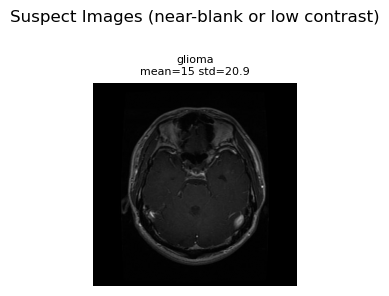

In [14]:
# Find images that are nearly all black or nearly all white,
# which could be corrupt, placeholder, or low-quality scans.

DARK_THRESH = 15     # mean intensity below this = suspiciously dark
BRIGHT_THRESH = 240  # mean intensity above this = suspiciously bright
LOW_STD_THRESH = 10  # std below this = very little contrast

suspect_images = []

for fpath, cls, split in all_paths:
    img = cv2.imread(str(fpath), cv2.IMREAD_GRAYSCALE)
    if img is None:
        continue

    mean_val = img.mean()
    std_val = img.std()

    if mean_val < DARK_THRESH or mean_val > BRIGHT_THRESH or std_val < LOW_STD_THRESH:
        suspect_images.append({
            'path': str(fpath),
            'filename': Path(fpath).name,
            'class': cls,
            'split': split,
            'mean': float(mean_val),
            'std': float(std_val)
        })

print(f'=== Near-Blank / Low-Contrast Image Check (all {len(all_paths)} images) ===')
print(f'Suspect images found: {len(suspect_images)}')

if suspect_images:
    # Show up to 8
    n_show = min(len(suspect_images), 8)
    fig, axes = plt.subplots(1, n_show, figsize=(3 * n_show, 3))
    if n_show == 1:
        axes = [axes]
    for i in range(n_show):
        s = suspect_images[i]
        img = cv2.imread(s['path'], cv2.IMREAD_GRAYSCALE)
        axes[i].imshow(img, cmap='gray', vmin=0, vmax=255)
        axes[i].set_title(f'{s["class"]}\nmean={s["mean"]:.0f} std={s["std"]:.1f}', fontsize=8)
        axes[i].axis('off')
    plt.suptitle('Suspect Images (near-blank or low contrast)', fontsize=12)
    plt.tight_layout()
    plt.show()
else:
    print('✅ No near-blank or low-contrast images found.')


# Full Dataset Channel Analysis & Color Outlier Investigation

In [15]:
# Full dataset channel analysis
color_outliers = []  # store paths + metadata for any truly-color images
truly_gray_count = 0
single_channel_count = 0

for split_dir, split_name in [(TRAIN_DIR, 'Training'), (TEST_DIR, 'Testing')]:
    for cls in CLASSES:
        folder = split_dir / cls
        for fpath in sorted(folder.iterdir()):
            if fpath.suffix.lower() not in ('.jpg', '.jpeg', '.png'):
                continue
            img = cv2.imread(str(fpath))
            if img is None:
                continue
            if len(img.shape) == 2:
                single_channel_count += 1
            elif np.array_equal(img[:,:,0], img[:,:,1]) and np.array_equal(img[:,:,1], img[:,:,2]):
                truly_gray_count += 1
            else:
                # Measure how "colorful" the image actually is
                # Max absolute difference between any two channels
                diff_br = np.abs(img[:,:,0].astype(int) - img[:,:,2].astype(int))
                diff_bg = np.abs(img[:,:,0].astype(int) - img[:,:,1].astype(int))
                diff_gr = np.abs(img[:,:,1].astype(int) - img[:,:,2].astype(int))
                max_diff = max(diff_br.max(), diff_bg.max(), diff_gr.max())
                mean_diff = np.mean([diff_br.mean(), diff_bg.mean(), diff_gr.mean()])
                
                color_outliers.append({
                    'path': str(fpath),
                    'filename': fpath.name,
                    'class': cls,
                    'split': split_name,
                    'width': img.shape[1],
                    'height': img.shape[0],
                    'max_channel_diff': int(max_diff),
                    'mean_channel_diff': float(mean_diff)
                })

total = single_channel_count + truly_gray_count + len(color_outliers)
print(f'Full dataset channel analysis ({total} images):')
print(f'  Single channel (grayscale):          {single_channel_count}')
print(f'  3-channel but identical (grayscale):  {truly_gray_count}')
print(f'  3-channel with color differences:     {len(color_outliers)}')
print(f'\nColor outlier breakdown by split:')
for split in ['Training', 'Testing']:
    split_outliers = [o for o in color_outliers if o['split'] == split]
    print(f'  {split}: {len(split_outliers)}')
print(f'\nColor outlier breakdown by class:')
for cls in CLASSES:
    cls_outliers = [o for o in color_outliers if o['class'] == cls]
    print(f'  {cls}: {len(cls_outliers)}')

Full dataset channel analysis (7200 images):
  Single channel (grayscale):          0
  3-channel but identical (grayscale):  7071
  3-channel with color differences:     129

Color outlier breakdown by split:
  Training: 91
  Testing: 38

Color outlier breakdown by class:
  glioma: 0
  meningioma: 0
  notumor: 129
  pituitary: 0
